In [ ]:
# Install runtime packages into the current notebook kernel
# Uses IPython %pip magic so packages install into the notebook's Python environment
# Adjust the list below if you need other packages
%pip install -q catboost scikit-learn imbalanced-learn seaborn matplotlib xgboost nbconvert

# Quick check
import importlib
for pkg in ('catboost','sklearn','imbalanced_learn','seaborn','matplotlib','xgboost'):
    try:
        m = importlib.import_module(pkg)
        print(f"{pkg}: OK ->", getattr(m, '__version__', 'unknown'))
    except Exception as e:
        print(f"{pkg}: NOT INSTALLED ({e})")


In [4]:
# Quick external-check: run cb_env's python to verify CatBoost is installed there
import subprocess
cb_py = r"C:\Users\nigam\OneDrive\Desktop\New folpractice 2der\cb_env\Scripts\python.exe"
try:
    out = subprocess.check_output([cb_py, "-c", "import catboost; print(catboost.__version__)"], stderr=subprocess.STDOUT, text=True)
    print('cb_env catboost OK ->', out.strip())
except Exception as e:
    print('cb_env check failed:', e)


cb_env catboost OK -> 1.2.8


In [2]:
# Install CatBoost in this notebook kernel and verify import
import sys
print('Notebook Python:', sys.executable)
import subprocess
try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost"])
except Exception as e:
    print('pip install failed:', e)

try:
    import catboost
    print('CATBOOST_OK', catboost.__version__)
except Exception as e:
    print('import failed:', e)


Notebook Python: c:\Users\nigam\OneDrive\Desktop\New folpractice 2der\.venv\Scripts\python.exe
pip install failed: Command '['c:\\Users\\nigam\\OneDrive\\Desktop\\New folpractice 2der\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'catboost']' returned non-zero exit status 1.
import failed: No module named 'catboost'


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
from catboost import CatBoostClassifier
print("CatBoost is ready!")


ModuleNotFoundError: No module named 'catboost'

In [2]:
from catboost import CatBoostClassifier

ModuleNotFoundError: No module named 'catboost'

In [4]:
df = pd.read_csv('C:/Users/nigam/Downloads/Mental Health Dataset.csv.zip')

In [5]:
df.isnull().sum()

Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

In [6]:
df['self_employed'].fillna('No', inplace=True)


In [7]:
df.isnull().sum()

Timestamp                  0
Gender                     0
Country                    0
Occupation                 0
self_employed              0
family_history             0
treatment                  0
Days_Indoors               0
Growing_Stress             0
Changes_Habits             0
Mental_Health_History      0
Mood_Swings                0
Coping_Struggles           0
Work_Interest              0
Social_Weakness            0
mental_health_interview    0
care_options               0
dtype: int64

In [8]:
df.drop('Timestamp', axis=1, inplace=True)

In [9]:
df.head()

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,Female,United States,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Gender                   292364 non-null  object
 1   Country                  292364 non-null  object
 2   Occupation               292364 non-null  object
 3   self_employed            292364 non-null  object
 4   family_history           292364 non-null  object
 5   treatment                292364 non-null  object
 6   Days_Indoors             292364 non-null  object
 7   Growing_Stress           292364 non-null  object
 8   Changes_Habits           292364 non-null  object
 9   Mental_Health_History    292364 non-null  object
 10  Mood_Swings              292364 non-null  object
 11  Coping_Struggles         292364 non-null  object
 12  Work_Interest            292364 non-null  object
 13  Social_Weakness          292364 non-null  object
 14  mental_health_interv

In [11]:
df.shape

(292364, 16)

In [12]:
target = 'treatment'
y = df[target]
X = df.drop(columns=[target, 'mental_health_interview'])

In [13]:
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
print("\nEncoded categorical columns:", categorical_cols)


Encoded categorical columns: Index(['Gender', 'Country', 'Occupation', 'self_employed', 'family_history',
       'Days_Indoors', 'Growing_Stress', 'Changes_Habits',
       'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles',
       'Work_Interest', 'Social_Weakness', 'care_options'],
      dtype='object')


In [14]:

df_encoded = pd.get_dummies(df, drop_first=True)


In [15]:
print(df_encoded.columns)


Index(['Gender_Male', 'Country_Belgium', 'Country_Bosnia and Herzegovina',
       'Country_Brazil', 'Country_Canada', 'Country_Colombia',
       'Country_Costa Rica', 'Country_Croatia', 'Country_Czech Republic',
       'Country_Denmark', 'Country_Finland', 'Country_France',
       'Country_Georgia', 'Country_Germany', 'Country_Greece', 'Country_India',
       'Country_Ireland', 'Country_Israel', 'Country_Italy', 'Country_Mexico',
       'Country_Moldova', 'Country_Netherlands', 'Country_New Zealand',
       'Country_Nigeria', 'Country_Philippines', 'Country_Poland',
       'Country_Portugal', 'Country_Russia', 'Country_Singapore',
       'Country_South Africa', 'Country_Sweden', 'Country_Switzerland',
       'Country_Thailand', 'Country_United Kingdom', 'Country_United States',
       'Occupation_Corporate', 'Occupation_Housewife', 'Occupation_Others',
       'Occupation_Student', 'self_employed_Yes', 'family_history_Yes',
       'treatment_Yes', 'Days_Indoors_15-30 days', 'Days_Indoor

In [16]:

df['treatment'] = df['treatment'].map({'Yes': 1, 'No': 0})

y = df['treatment']
X = df.drop('treatment', axis=1)

X = pd.get_dummies(X, drop_first=True)


In [17]:
corr = X.corrwith(y).sort_values(ascending=False)
print(corr)


family_history_Yes            0.366781
care_options_Yes              0.293437
Country_United States         0.090884
mental_health_interview_No    0.086694
Country_Poland                0.052648
                                ...   
Country_Italy                -0.073959
Country_Israel               -0.073959
Country_France               -0.090703
care_options_Not sure        -0.133983
Gender_Male                  -0.177203
Length: 62, dtype: float64


In [18]:
drop_cols = [col for col in X.columns 
             if col.startswith('Country_') or col.startswith('Gender_')]

X_clean = X.drop(columns=drop_cols)


In [19]:
low_corr = corr[abs(corr) < 0.01].index
X = X.drop(columns=low_corr)
print("\nDropped low-correlation features:", list(low_corr))


Dropped low-correlation features: ['Coping_Struggles_Yes', 'Work_Interest_Yes', 'Occupation_Others', 'Occupation_Student', 'Days_Indoors_Go out Every day', 'Changes_Habits_No', 'Days_Indoors_15-30 days', 'Social_Weakness_No', 'Days_Indoors_More than 2 months', 'Social_Weakness_Yes', 'Days_Indoors_31-60 days', 'Country_Switzerland', 'Occupation_Housewife', 'Country_Germany', 'Work_Interest_No', 'Mood_Swings_Low', 'Changes_Habits_Yes', 'Mental_Health_History_Yes', 'Mood_Swings_Medium', 'Growing_Stress_No', 'Country_Ireland', 'Mental_Health_History_No', 'Occupation_Corporate', 'Country_United Kingdom']


In [20]:
if 'Growing_Stress' in X.columns and 'Coping_Struggles' in X.columns:
    X['Stress_Coping_Ratio'] = X['Growing_Stress'] / (X['Coping_Struggles'] + 1)
if 'Days_Indoors' in X.columns and 'Social_Weakness' in X.columns:
    X['Social_Activity'] = X['Days_Indoors'] * X['Social_Weakness']

print("\nShape after feature engineering:", X.shape)


Shape after feature engineering: (292364, 38)


In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("\nTraining set shape:", X_train.shape, "Test set shape:", X_test.shape)


Training set shape: (233891, 38) Test set shape: (58473, 38)


In [23]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Shape after SMOTE:", X_train_res.shape)


Shape after SMOTE: (236170, 38)


In [24]:
models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}


In [25]:
param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [5, 10]
}
param_grid_xgb = {
    'n_estimators': [100],
    'max_depth': [6],
    'learning_rate': [0.1]
}

grids = {
    "RandomForest": (models['RandomForest'], param_grid_rf),
    "XGBoost": (models['XGBoost'], param_grid_xgb)
}

In [26]:
for name, (model, params) in grids.items():
    print(f"\n--- Training {name} ---")

    grid = GridSearchCV(model, params, cv=3, scoring='accuracy', n_jobs=1)

    grid.fit(X_train_res, y_train_res)
    
    best_model = grid.best_estimator_
    print(f"Best params for {name}:", grid.best_params_)
    
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:,1]
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC for {name}: {roc_auc:.4f}")


--- Training RandomForest ---
Best params for RandomForest: {'max_depth': 10, 'n_estimators': 100}
Confusion Matrix:
[[20122  8830]
 [ 5897 23624]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73     28952
           1       0.73      0.80      0.76     29521

    accuracy                           0.75     58473
   macro avg       0.75      0.75      0.75     58473
weighted avg       0.75      0.75      0.75     58473

ROC-AUC for RandomForest: 0.8309

--- Training XGBoost ---


c:\Users\nigam\OneDrive\Desktop\New folpractice 2der\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:20:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\nigam\OneDrive\Desktop\New folpractice 2der\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:20:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\nigam\OneDrive\Desktop\New folpractice 2der\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:20:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\nigam\OneDrive\Desktop\New folpractice 2der\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:20:57] W

Best params for XGBoost: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
Confusion Matrix:
[[20300  8652]
 [ 6132 23389]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73     28952
           1       0.73      0.79      0.76     29521

    accuracy                           0.75     58473
   macro avg       0.75      0.75      0.75     58473
weighted avg       0.75      0.75      0.75     58473

ROC-AUC for XGBoost: 0.8294


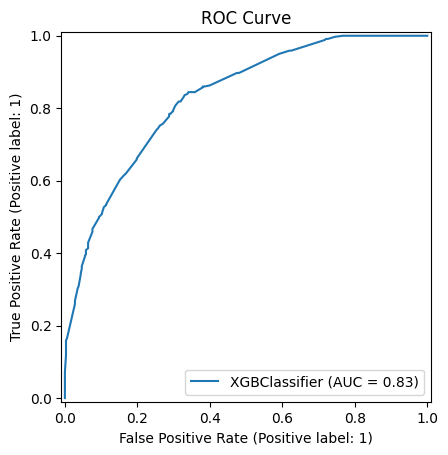

In [27]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve")
plt.show()


In [28]:
new_user_array = np.array([[0, 1, 5, 3, 2, 1]])
new_user_df = pd.DataFrame(new_user_array, columns=X.columns[:6])


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [31]:
new_user_df = new_user_df.reindex(columns=X.columns, fill_value=0)


In [32]:
new_user_scaled = scaler.transform(new_user_df)

proba = best_model.predict_proba(new_user_scaled)[0][1]
threshold = 0.5
pred = 1 if proba >= threshold else 0

print("Predicted class:", pred)
print("Risk probability:", proba)


Predicted class: 0
Risk probability: 0.0022410727


In [33]:
new_user_array = np.array([[3, 5, 5, 3, 8, 5]])
new_user_df = pd.DataFrame(new_user_array, columns=X.columns[:6])

In [34]:
new_user_df = new_user_df.reindex(columns=X.columns, fill_value=0)

In [35]:
new_user_scaled = scaler.transform(new_user_df)

proba = best_model.predict_proba(new_user_scaled)[0][1]
threshold = 0.5
pred = 1 if proba >= threshold else 0

print("Predicted class:", pred)
print("Risk probability:", proba)


Predicted class: 0
Risk probability: 0.0033957292
